In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
# from erddapClient import ERDDAP_Griddap
from netCDF4 import Dataset
import cmocean
from mpl_toolkits.basemap import Basemap
from matplotlib import colors
from scipy.stats import linregress
import pandas as pd
import xarray as xr

In [2]:
# Global Ocean Colour (Copernicus-GlobColour), Bio-Geo-Chemical, L4 (monthly and interpolated) from Satellite Observations (Near Real Time)
file_id = Dataset('../../data/chl/chl_1999_2024_day_aloha_l3_2.nc')
chl = file_id.variables["CHL"][:]
time = file_id.variables["time"][:]
lat = file_id.variables["latitude"][:]
lon = file_id.variables["longitude"][:]
file_id.close()

In [3]:
timedelta_vector = (time * np.timedelta64(1, 'D')).astype('timedelta64[ns]')
base_date = np.datetime64('1900-01-01')
date_vector = base_date + timedelta_vector
chl_time = pd.to_datetime(date_vector)

In [4]:
# Target coordinates
target_lat = 22.75
target_lon = -158.0

# Find nearest indices
lat_idx = np.argmin(np.abs(lat - target_lat))
lon_idx = np.argmin(np.abs(lon - target_lon))

# 3x3 box (±1 pixel around center)
lat_slice = slice(lat_idx - 1, lat_idx + 2)
lon_slice = slice(lon_idx - 1, lon_idx + 2)

chl_crop = chl[:, lat_slice, lon_slice]
lat_crop = lat[lat_slice]
lon_crop = lon[lon_slice]

# Filter to <= 2022-12-30
time_mask = chl_time <= '2022-12-30'

chl_crop = chl_crop[time_mask, :, :]
chl_time = chl_time[time_mask]

print(f"Time range: {chl_time[0].date()} to {chl_time[-1].date()}")
print(f"Cropped shape: {chl_crop.shape}")
print(f"Nearest lat: {lat[lat_idx]:.4f}, Nearest lon: {lon[lon_idx]:.4f}")
print(f"Lat window: {lat_crop}")
print(f"Lon window: {lon_crop}")
print(f"Cropped shape: {chl_crop.shape}")

Time range: 1999-01-01 to 2022-12-30
Cropped shape: (8765, 3, 3)
Nearest lat: 22.7708, Nearest lon: -158.0208
Lat window: [22.729164 22.770832 22.812498]
Lon window: [-158.0625  -158.02083 -157.97917]
Cropped shape: (8765, 3, 3)


In [5]:
# Build an xarray DataArray with the time coordinate
chl_xa = xr.DataArray(
    chl_crop,
    dims=['time', 'lat', 'lon'],
    coords={
        'time': chl_time,
        'lat': lat_crop,
        'lon': lon_crop
    }
)

# Compute median climatology for each day of year (1–366)
# chl_clim = chl_xa.groupby('time.dayofyear').median(dim='time')
chl_clim = chl_xa.groupby('time.month').median(dim='time', skipna=True)
chl_anom = chl_xa.groupby('time.month') - chl_clim

print(f"Climatology shape: {chl_clim.shape}")
print(f"Anomaly shape: {chl_anom.shape}")
print(f"Anomaly mean (should be near zero): {float(chl_anom.mean()):.6f}")

# Flatten spatial dims and build a DataFrame
chl_flat = chl_anom.values.reshape(len(chl_time), -1)
df = pd.DataFrame(chl_flat, index=chl_time)
df['month'] = df.index.month

# Melt to long format for boxplot
df_melt = df.melt(id_vars='month', var_name='pixel', value_name='chl_anom')

Climatology shape: (12, 3, 3)
Anomaly shape: (8765, 3, 3)
Anomaly mean (should be near zero): 0.001663


In [6]:
# --- Raw DataFrame ---
chl_flat_raw = chl_xa.values.reshape(len(chl_time), -1)
df_raw = pd.DataFrame(chl_flat_raw, index=chl_time)
df_raw['month'] = df_raw.index.month
df_melt_raw = df_raw.melt(id_vars='month', var_name='pixel', value_name='chl')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

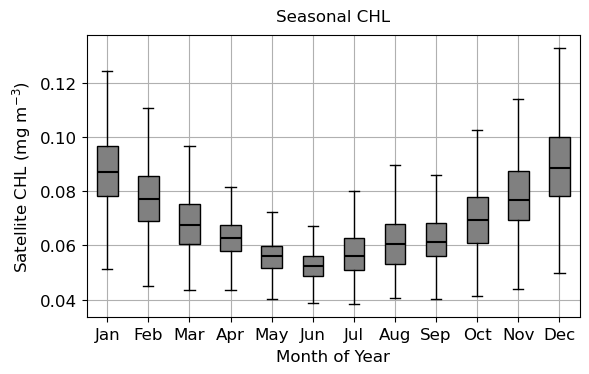

In [22]:

# --- Figure 1: Raw monthly CHL ---
fig1, ax1 = plt.subplots(figsize=(6, 4))
df_melt_raw.boxplot(column='chl', by='month', ax=ax1,
                    showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor='grey', edgecolor='black'),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    flierprops=dict(markeredgecolor='black'))

ax1.set_xlabel('Month of Year', fontsize=12, fontweight='normal', labelpad=5)
ax1.set_ylabel('Satellite CHL (mg m$^{-3}$)', fontsize=12, fontweight='normal', labelpad=5)
ax1.set_title('Seasonal CHL', fontsize=12, pad=10)
fig1.suptitle('')
ax1.set_xticklabels(month_labels, fontsize=12)
ax1.tick_params(axis='y', labelsize=12)

plt.tight_layout()
fig1.savefig('../../figures/chl_raw_boxplot_20260313.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

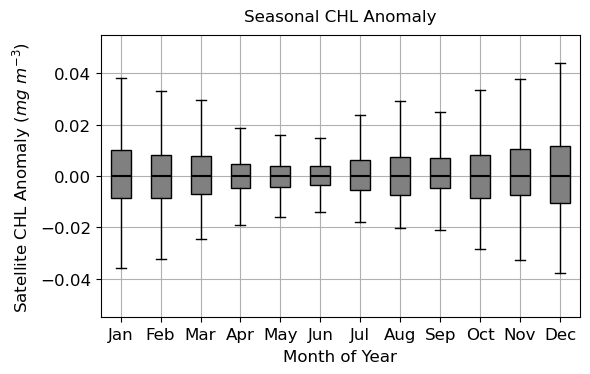

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
df_melt.boxplot(column='chl_anom', by='month', ax=ax, #grid = False,
                showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='grey', edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(markeredgecolor='black'))

ax.set_xlabel('Month of Year', fontsize=12, fontweight='normal', labelpad=5)
ax.set_ylabel('Satellite CHL Anomaly ($mg$ $m^{-3}$)', fontsize=12, fontweight='normal', labelpad=5)
ax.set_title('Seasonal CHL Anomaly', fontsize=12, pad=10)
ax.set_ylim(-0.055, 0.055)
fig.suptitle('')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticklabels(month_labels, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
fig.savefig('../../figures/20260313_seasonal_chl_anomaly_boxplot.pdf', dpi=600, bbox_inches='tight')
plt.show()